In [1]:
# Initial data peek for Fara training parquet files
from pathlib import Path
import glob
import json
from typing import Any
import pandas as pd

# ---- Configure this path first ----
# Examples:
#   '/gpfs/projects/raivn/reza/MolmoWeb-SyntheticTrajs/data/*.parquet'
#   '/path/to/data/from_template-00000.parquet'
DATA_GLOB = '/gpfs/scrubbed/reza/MolmoWeb-SyntheticTrajs/data/*.parquet'
N_ROWS = 5

files = sorted(glob.glob(DATA_GLOB))
print(f'Found {len(files)} parquet file(s)')
if not files:
    raise FileNotFoundError(f'No parquet files matched: {DATA_GLOB}')

print('First files:')
for f in files[:5]:
    print(' -', f)

# Load a small sample across files
df = pd.concat([pd.read_parquet(f).head(N_ROWS) for f in files[:2]], ignore_index=True)
print('\nLoaded sample shape:', df.shape)
print('Columns:', list(df.columns))
print('\nDtypes:\n', df.dtypes)

required = ['instruction', 'trajectory', 'images']
missing = [c for c in required if c not in df.columns]
if missing:
    print(f'\nWARNING: Missing expected columns: {missing}')

def _stringify_step(step: Any) -> str:
    """Mimics training-time target text extraction in scripts/train_fara.py."""
    if isinstance(step, str):
        return step
    if isinstance(step, dict):
        if 'thought' in step and 'action' in step:
            return f"Thought: {step['thought']}\\nAction: {step['action']}"
        if 'action' in step:
            return str(step['action'])
        return json.dumps(step, ensure_ascii=False)
    return str(step)

def _action_like(step: Any) -> bool:
    if isinstance(step, dict):
        keys = {k.lower() for k in step.keys()}
        if {'action', 'tool', 'command', 'click', 'type', 'scroll'} & keys:
            return True
        # Also inspect values for common action words
        text = json.dumps(step, ensure_ascii=False).lower()
    else:
        text = str(step).lower()
    action_words = ['click', 'type', 'scroll', 'select', 'press', 'navigate', 'open', 'submit']
    return any(w in text for w in action_words)

print('\n=== Row-by-row preview ===')
for ridx, row in df.head(N_ROWS).iterrows():
    instruction = row.get('instruction')
    traj = row.get('trajectory') or []
    imgs = row.get('images')

    print(f'\n--- Sample {ridx} ---')
    print('instruction:', (instruction[:200] + '...') if isinstance(instruction, str) and len(instruction) > 200 else instruction)
    print('trajectory length:', len(traj) if isinstance(traj, list) else type(traj))
    print('images length:', len(imgs) if isinstance(imgs, list) else type(imgs))

    # Show image entry structure only (not raw bytes)
    if isinstance(imgs, list) and imgs:
        first_img = imgs[0]
        if isinstance(first_img, dict):
            print('first image keys:', list(first_img.keys()))
            print('first image bytes length:', len(first_img.get('bytes') or b''))
        else:
            print('first image type:', type(first_img))

    # Show first few target texts derived from trajectory
    if isinstance(traj, list) and traj:
        preview_steps = traj[:3]
        for i, s in enumerate(preview_steps):
            target_text = _stringify_step(s)
            print(f'target step {i}:', (target_text[:220] + '...') if len(target_text) > 220 else target_text)
        action_hits = sum(_action_like(s) for s in traj)
        print(f'action-like steps: {action_hits}/{len(traj)}')
    else:
        print('trajectory missing or not a list')

print('\nDone. Next: expand N_ROWS and inspect specific failure cases by sample_id.')

Found 35 parquet file(s)
First files:
 - /gpfs/scrubbed/reza/MolmoWeb-SyntheticTrajs/data/from_template-00000.parquet
 - /gpfs/scrubbed/reza/MolmoWeb-SyntheticTrajs/data/from_template-00001.parquet
 - /gpfs/scrubbed/reza/MolmoWeb-SyntheticTrajs/data/from_template-00002.parquet
 - /gpfs/scrubbed/reza/MolmoWeb-SyntheticTrajs/data/multi_agent-00000.parquet
 - /gpfs/scrubbed/reza/MolmoWeb-SyntheticTrajs/data/multi_agent-00001.parquet

Loaded sample shape: (10, 4)
Columns: ['sample_id', 'instruction', 'trajectory', 'images']

Dtypes:
 sample_id      object
instruction    object
trajectory     object
images         object
dtype: object

=== Row-by-row preview ===

--- Sample 0 ---
instruction: {"high_level": "Find and list the top results for 'Chicken Tikka Masala' on Allrecipes.", "mid_level": "Search Allrecipes for 'Chicken Tikka Masala,' pick the top recipes, and list their titles.", "lo...
trajectory length: <class 'str'>
images length: <class 'numpy.ndarray'>
trajectory missing or not a

In [2]:
df.head()

,sample_id,instruction,trajectory,images
0,96a9ddfb73229cc5d8d71ce086e71fe6e3b48de8f60b81...,"{""high_level"": ""Find and list the top results ...","{""1"": {""screenshot"": ""screenshot_001.png"", ""ot...","[{'bytes': b""\x89PNG\r\n\x1a\n\x00\x00\x00\rIH..."
1,b15b1176c9e0065eab753e7093cef88fa51590d9f95145...,"{""high_level"": ""Find and note down the top thr...","{""1"": {""screenshot"": ""screenshot_001.png"", ""ot...","[{'bytes': b""\x89PNG\r\n\x1a\n\x00\x00\x00\rIH..."
2,0382c2b892d58d7aa95a2b39cbc690c5926366e65230d2...,"{""high_level"": ""Find and summarize the cooking...","{""1"": {""screenshot"": ""screenshot_001.png"", ""ot...","[{'bytes': b""\x89PNG\r\n\x1a\n\x00\x00\x00\rIH..."
3,f66be34b2f37733a8fca4fc8a937c1290f279388e4d193...,"{""high_level"": ""Locate and extract three 'Chic...","{""1"": {""screenshot"": ""screenshot_001.png"", ""ot...","[{'bytes': b""\x89PNG\r\n\x1a\n\x00\x00\x00\rIH..."
4,be8f625a86fec9fa8054dadea4a56de17c3bb877876405...,"{""high_level"": ""Explore Allrecipes for a few J...","{""1"": {""screenshot"": ""screenshot_001.png"", ""ot...","[{'bytes': b""\x89PNG\r\n\x1a\n\x00\x00\x00\rIH..."


In [ ]:
df['images'][0]

array([{'bytes': b"\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x05\x00\x00\x00\x02\xd0\x08\x02\x00\x00\x00@\x1fJ\x01\x00\x00\x10\xa5IDATx\x9c\xed\xd7\xc1\r\xc0 \x10\xc0\xb0\xd2\xfdw>\xb6\x00\x89\xd8\x13\xe4\x9b53\x1f\x00\x00\x00\xbc\xee\xbf\x1d\x00\x00\x00\x00'\x18`\x00\x00\x00\x12\x0c0\x00\x00\x00\t\x06\x18\x00\x00\x80\x04\x03\x0c\x00\x00@\x82\x01\x06\x00\x00 \xc1\x00\x03\x00\x00\x90`\x80\x01\x00\x00H0\xc0\x00\x00\x00$\x18`\x00\x00\x00\x12\x0c0\x00\x00\x00\t\x06\x18\x00\x00\x80\x04\x03\x0c\x00\x00@\x82\x01\x06\x00\x00 \xc1\x00\x03\x00\x00\x90`\x80\x01\x00\x00H0\xc0\x00\x00\x00$\x18`\x00\x00\x00\x12\x0c0\x00\x00\x00\t\x06\x18\x00\x00\x80\x04\x03\x0c\x00\x00@\x82\x01\x06\x00\x00 \xc1\x00\x03\x00\x00\x90`\x80\x01\x00\x00H0\xc0\x00\x00\x00$\x18`\x00\x00\x00\x12\x0c0\x00\x00\x00\t\x06\x18\x00\x00\x80\x04\x03\x0c\x00\x00@\x82\x01\x06\x00\x00 \xc1\x00\x03\x00\x00\x90`\x80\x01\x00\x00H0\xc0\x00\x00\x00$\x18`\x00\x00\x00\x12\x0c0\x00\x00\x00\t\x06\x18\x00\x00\x80\x04\x03\x0c\x00\x00@\x82\x01\x

In [3]:
df['trajectory'][0]

'{"1": {"screenshot": "screenshot_001.png", "other_obs": {"page_index": 0, "url": "about:blank", "open_pages_titles": [""], "open_pages_urls": ["about:blank"]}, "action": {"action_str": "goto(url=\'https://www.allrecipes.com\')", "action_description": "go to https://www.allrecipes.com", "action_output": {"thought": "The user wants to find the top 3 \'Chicken Tikka Masala\' recipes on Allrecipes. I need to navigate to the Allrecipes website first.", "action": {"url": "https://www.allrecipes.com"}, "action_name": "goto"}}, "action_timestamp": 1769115342.489504, "image_w": 1280, "image_h": 720}, "2": {"screenshot": "screenshot_002.png", "other_obs": {"page_index": 0, "url": "https://www.allrecipes.com/", "open_pages_titles": ["Allrecipes | Recipes, How-Tos, Videos and More"], "open_pages_urls": ["https://www.allrecipes.com/"]}, "action": {"action_str": "click(bid=\'158\', button=\'left\')", "action_description": "left click on textbox with value \'Search the site\' (element is clickable)"

In [4]:
sample_traj = json.loads(df['trajectory'][0])

In [9]:
sample_traj['1']

{'screenshot': 'screenshot_001.png',
 'other_obs': {'page_index': 0,
  'url': 'about:blank',
  'open_pages_titles': [''],
  'open_pages_urls': ['about:blank']},
 'action': {'action_str': "goto(url='https://www.allrecipes.com')",
  'action_description': 'go to https://www.allrecipes.com',
  'action_output': {'thought': "The user wants to find the top 3 'Chicken Tikka Masala' recipes on Allrecipes. I need to navigate to the Allrecipes website first.",
   'action': {'url': 'https://www.allrecipes.com'},
   'action_name': 'goto'}},
 'action_timestamp': 1769115342.489504,
 'image_w': 1280,
 'image_h': 720}

In [10]:
sample_traj['2']

{'screenshot': 'screenshot_002.png',
 'other_obs': {'page_index': 0,
  'url': 'https://www.allrecipes.com/',
  'open_pages_titles': ['Allrecipes | Recipes, How-Tos, Videos and More'],
  'open_pages_urls': ['https://www.allrecipes.com/']},
 'action': {'action_str': "click(bid='158', button='left')",
  'action_description': "left click on textbox with value 'Search the site' (element is clickable)",
  'action_output': {'thought': "I have successfully navigated to Allrecipes. My next step is to search for 'Chicken Tikka Masala'. I will click on the search textbox and then type the search term.",
   'action': {'bid': '158',
    'button': 'left',
    'click_type': 'single',
    'bbox': [305.453125, 38.0, 436.0, 36.0],
    'node_properties': {'role': 'textbox', 'value': 'Search the site'}},
   'action_name': 'click'}},
 'action_timestamp': 1769115438.237602,
 'image_w': 1280,
 'image_h': 720}

In [11]:
sample_traj['3']

{'screenshot': 'screenshot_003.png',
 'other_obs': {'page_index': 0,
  'url': 'https://www.allrecipes.com/',
  'open_pages_titles': ['Allrecipes | Recipes, How-Tos, Videos and More'],
  'open_pages_urls': ['https://www.allrecipes.com/']},
 'action': {'action_str': "keyboard_type(text='Chicken Tikka Masala\\n')",
  'action_description': "type 'Chicken Tikka Masala\n'",
  'action_output': {'thought': "I have already clicked on the search bar. Now I need to type 'Chicken Tikka Masala' into the search textbox and press Enter to initiate the search.",
   'action': {'text': 'Chicken Tikka Masala\n'},
   'action_name': 'keyboard_type'}},
 'action_timestamp': 1769115460.44237,
 'image_w': 1280,
 'image_h': 720}

Using bbox from step: 2
Raw bbox: [305.453125, 38.0, 436.0, 36.0]


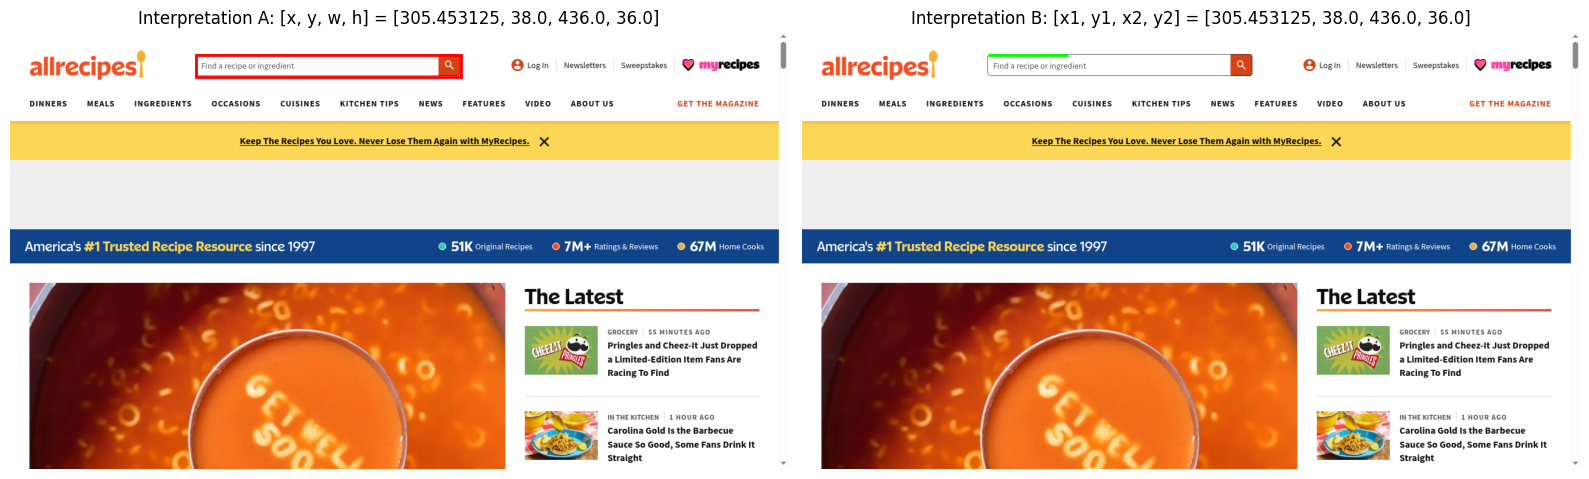

Image size (W,H): (1280, 720)
If xywh -> x+w,y+h = (741.453125, 74.0)
If xyxy -> w,h = (130.546875, 0.0)
All detected bbox candidates: [('2', [305.453125, 38.0, 436.0, 36.0])]


In [14]:
# Visualize action bbox on first screenshot (row 0, frame 0)
import io
import json
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# 1) Get first screenshot bytes from dataframe
img_entry = df['images'][0][1]
assert isinstance(img_entry, dict) and img_entry.get('bytes') is not None, "Expected df['images'][0][0]['bytes']"
img = Image.open(io.BytesIO(img_entry['bytes'])).convert('RGB')

# 2) Robustly get trajectory object
traj_obj = sample_traj
if isinstance(traj_obj, str):
    traj_obj = json.loads(traj_obj)

if not isinstance(traj_obj, dict):
    raise TypeError(f"Expected trajectory dict, got {type(traj_obj)}")

def extract_bbox_candidates(traj_dict):
    """Return list of (step_name, bbox) found in common schema variants."""
    candidates = []

    # Case A: top-level action dict
    if 'action' in traj_dict and isinstance(traj_dict['action'], dict):
        try:
            bbox = traj_dict['action']['action_output']['action']['bbox']
            if isinstance(bbox, (list, tuple)) and len(bbox) == 4:
                candidates.append(('top-level-action', list(bbox)))
        except Exception:
            pass

    # Case B: step-indexed dict, e.g. {'1': {...}, '2': {...}}
    for k, v in traj_dict.items():
        if not isinstance(v, dict):
            continue
        # common nesting used by your sample
        try:
            bbox = v['action']['action_output']['action']['bbox']
            if isinstance(bbox, (list, tuple)) and len(bbox) == 4:
                candidates.append((str(k), list(bbox)))
                continue
        except Exception:
            pass
        # fallback nesting
        try:
            bbox = v['action_output']['action']['bbox']
            if isinstance(bbox, (list, tuple)) and len(bbox) == 4:
                candidates.append((str(k), list(bbox)))
        except Exception:
            pass

    return candidates

cands = extract_bbox_candidates(traj_obj)
if not cands:
    raise KeyError("Could not find any bbox at expected paths. Inspect sample_traj keys/structure first.")

# choose first detected bbox
step_name, bbox = cands[0]
x, y, a, b = [float(z) for z in bbox]

print(f"Using bbox from step: {step_name}")
print("Raw bbox:", bbox)

# 3) Draw two interpretations so you can verify which matches your data
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: assume bbox is [x, y, w, h]
axes[0].imshow(img)
axes[0].add_patch(Rectangle((x, y), a, b, fill=False, edgecolor='red', linewidth=2))
axes[0].set_title(f'Interpretation A: [x, y, w, h] = {bbox}')
axes[0].axis('off')

# Right: assume bbox is [x1, y1, x2, y2]
w2 = max(0.0, a - x)
h2 = max(0.0, b - y)
axes[1].imshow(img)
axes[1].add_patch(Rectangle((x, y), w2, h2, fill=False, edgecolor='lime', linewidth=2))
axes[1].set_title(f'Interpretation B: [x1, y1, x2, y2] = {bbox}')
axes[1].axis('off')

plt.tight_layout()
plt.show()

print('Image size (W,H):', img.size)
print('If xywh -> x+w,y+h =', (x + a, y + b))
print('If xyxy -> w,h =', (w2, h2))
print('All detected bbox candidates:', cands[:5])

In [16]:
# Count and inspect action types used in trajectories
import json
import re
from collections import Counter, defaultdict

MAX_ROWS = 5000  # set e.g. 2000 to limit scan for speed

def _to_traj_obj(x):
    if isinstance(x, dict):
        return x
    if isinstance(x, str):
        try:
            return json.loads(x)
        except Exception:
            return None
    return None

def _normalize_action_name(name):
    if name is None:
        return None
    name = str(name).strip().lower()
    if not name:
        return None
    # unify common aliases
    aliases = {
        'go_to': 'goto',
        'go-to': 'goto',
        'navigate': 'goto',
        'type_text': 'type',
        'left_click': 'click',
    }
    return aliases.get(name, name)

def _extract_actions_from_step(step):
    """Return list of (action_name, action_str_or_desc) from one step dict."""
    found = []
    if not isinstance(step, dict):
        return found

    # Pattern 1: step['action']['action_output']['action_name']
    try:
        ao = step.get('action', {}).get('action_output', {})
        action_name = _normalize_action_name(ao.get('action_name'))
        action_str = step.get('action', {}).get('action_str')
        if action_name:
            found.append((action_name, action_str))
    except Exception:
        pass

    # Pattern 2: step['action_output']['action_name']
    try:
        ao = step.get('action_output', {})
        action_name = _normalize_action_name(ao.get('action_name'))
        if action_name:
            found.append((action_name, None))
    except Exception:
        pass

    # Pattern 3: infer from action_str like "click(...)"
    cand_strings = []
    for k in ('action_str', 'action_description'):
        v = step.get('action', {}).get(k) if isinstance(step.get('action'), dict) else None
        if isinstance(v, str):
            cand_strings.append(v)
        v2 = step.get(k)
        if isinstance(v2, str):
            cand_strings.append(v2)

    for s in cand_strings:
        m = re.match(r'^\s*([a-zA-Z_\-]+)\s*\(', s)
        if m:
            found.append((_normalize_action_name(m.group(1)), s))
        else:
            # keyword fallback
            low = s.lower()
            for kw in ['click', 'goto', 'type', 'scroll', 'select', 'hover', 'press', 'submit']:
                if kw in low:
                    found.append((_normalize_action_name(kw), s))
                    break

    # dedup within step
    out = []
    seen = set()
    for a, src in found:
        if not a:
            continue
        key = (a, src)
        if key not in seen:
            seen.add(key)
            out.append((a, src))
    return out

action_counts = Counter()
action_examples = defaultdict(list)
rows_scanned = 0
steps_scanned = 0

rows_iter = df.itertuples(index=False)
for i, row in enumerate(rows_iter):
    if MAX_ROWS is not None and i >= MAX_ROWS:
        break

    # traj_raw = getattr(row, 'trajectory', None)
    traj_raw = row.trajectory
    traj_obj = _to_traj_obj(traj_raw)
    if not isinstance(traj_obj, dict):
        continue

    rows_scanned += 1

    # step-indexed dict {'1': {...}, '2': {...}} or top-level action dict
    if 'action' in traj_obj:
        steps = [('top', traj_obj)]
    else:
        steps = list(traj_obj.items())

    for step_key, step_val in steps:
        steps_scanned += 1
        for action_name, src in _extract_actions_from_step(step_val):
            action_counts[action_name] += 1
            if src and len(action_examples[action_name]) < 3:
                action_examples[action_name].append(src)

print(f'Rows scanned: {rows_scanned}')
print(f'Steps scanned: {steps_scanned}')
print(f'Unique action names: {len(action_counts)}')

if not action_counts:
    print('No actions found with current extraction rules. Inspect one raw trajectory to adapt paths.')
else:
    print('\nAction frequency (desc):')
    for action, cnt in action_counts.most_common():
        print(f'- {action}: {cnt}')

    print('\nExample action strings/descriptions:')
    for action, exs in action_examples.items():
        print(f'\n[{action}]')
        for e in exs:
            print('  ', e[:180] + ('...' if len(e) > 180 else ''))

Rows scanned: 10
Steps scanned: 89
Unique action names: 8

Action frequency (desc):
- click: 74
- scroll: 22
- send_msg_to_user: 20
- goto: 10
- keyboard_type: 9
- type: 9
- keyboard_press: 2
- press: 2

Example action strings/descriptions:

[goto]
   goto(url='https://www.allrecipes.com')
   goto(url='https://www.allrecipes.com')
   goto(url='https://www.allrecipes.com')

[click]
   click(bid='158', button='left')
   left click on textbox with value 'Search the site' (element is clickable)
   click(bid='158', button='left')

[keyboard_type]
   keyboard_type(text='Chicken Tikka Masala\n')
   keyboard_type(text='Chicken Tikka Masala')
   keyboard_type(text='Thai Red Curry with Vegetables')

[type]
   type 'Chicken Tikka Masala
'
   type 'Chicken Tikka Masala'
   type 'Thai Red Curry with Vegetables'

[send_msg_to_user]
   send_msg_to_user(text="[ANSWER] 1. Chef John's Chicken Tikka Masala, 2. Chicken Tikka Masala, 3. Curry Stand Chicken Tikka Masala Sauce")
   send_msg_to_user(text='[EX

In [17]:
# Compare allowed actions from Fara prompt vs actions found in dataset
import re
from pathlib import Path

PROMPTS_PATH = Path('/gpfs/projects/raivn/reza/fara/src/fara/_prompts.py')
text = PROMPTS_PATH.read_text(encoding='utf-8')

# Extract allowed actions from the enum list in FaraComputerUse.parameters
enum_match = re.search(r'"enum"\s*:\s*\[(.*?)\]', text, flags=re.S)
if not enum_match:
    raise RuntimeError('Could not find action enum in _prompts.py')

allowed_actions = [
    m.group(1)
    for m in re.finditer(r'"([a-zA-Z_]+)"', enum_match.group(1))
]
allowed_set = set(allowed_actions)

print('Allowed actions from Fara prompt:')
print(sorted(allowed_actions))

# Use action_counts from previous cell (Cell 11)
if 'action_counts' not in globals():
    raise RuntimeError('Run Cell 11 first to compute action_counts from dataset')

dataset_actions = set(action_counts.keys())

# Small alias normalization for easier comparison
alias = {
    'click': 'left_click',
    'keypress': 'key',
    'hover': 'mouse_move',
    'sleep': 'wait',
    'stop': 'terminate',
    'goto': 'visit_url',
}
normalized_dataset_actions = set(alias.get(a, a) for a in dataset_actions)

in_dataset_not_prompt = sorted(a for a in normalized_dataset_actions if a not in allowed_set)
in_prompt_not_dataset = sorted(a for a in allowed_set if a not in normalized_dataset_actions)
intersection = sorted(a for a in normalized_dataset_actions if a in allowed_set)

print('\nDataset actions (raw):', sorted(dataset_actions))
print('Dataset actions (normalized for comparison):', sorted(normalized_dataset_actions))

print('\nIntersection (present in both):')
print(intersection)

print('\nIn dataset but NOT in prompt enum:')
print(in_dataset_not_prompt if in_dataset_not_prompt else 'None')

print('\nIn prompt enum but NOT seen in dataset sample:')
print(in_prompt_not_dataset if in_prompt_not_dataset else 'None')

print('\nTop dataset action frequencies:')
for action, cnt in action_counts.most_common(20):
    print(f'- {action}: {cnt}')

Allowed actions from Fara prompt:
['history_back', 'key', 'left_click', 'mouse_move', 'pause_and_memorize_fact', 'scroll', 'terminate', 'type', 'visit_url', 'wait', 'web_search']

Dataset actions (raw): ['click', 'goto', 'keyboard_press', 'keyboard_type', 'press', 'scroll', 'send_msg_to_user', 'type']
Dataset actions (normalized for comparison): ['keyboard_press', 'keyboard_type', 'left_click', 'press', 'scroll', 'send_msg_to_user', 'type', 'visit_url']

Intersection (present in both):
['left_click', 'scroll', 'type', 'visit_url']

In dataset but NOT in prompt enum:
['keyboard_press', 'keyboard_type', 'press', 'send_msg_to_user']

In prompt enum but NOT seen in dataset sample:
['history_back', 'key', 'mouse_move', 'pause_and_memorize_fact', 'terminate', 'wait', 'web_search']

Top dataset action frequencies:
- click: 74
- scroll: 22
- send_msg_to_user: 20
- goto: 10
- keyboard_type: 9
- type: 9
- keyboard_press: 2
- press: 2


In [ ]:
df.head()

,sample_id,instruction,trajectory,images
0,96a9ddfb73229cc5d8d71ce086e71fe6e3b48de8f60b81...,"{""high_level"": ""Find and list the top results ...","{""1"": {""screenshot"": ""screenshot_001.png"", ""ot...","[{'bytes': b""\x89PNG\r\n\x1a\n\x00\x00\x00\rIH..."
1,b15b1176c9e0065eab753e7093cef88fa51590d9f95145...,"{""high_level"": ""Find and note down the top thr...","{""1"": {""screenshot"": ""screenshot_001.png"", ""ot...","[{'bytes': b""\x89PNG\r\n\x1a\n\x00\x00\x00\rIH..."
2,0382c2b892d58d7aa95a2b39cbc690c5926366e65230d2...,"{""high_level"": ""Find and summarize the cooking...","{""1"": {""screenshot"": ""screenshot_001.png"", ""ot...","[{'bytes': b""\x89PNG\r\n\x1a\n\x00\x00\x00\rIH..."
3,f66be34b2f37733a8fca4fc8a937c1290f279388e4d193...,"{""high_level"": ""Locate and extract three 'Chic...","{""1"": {""screenshot"": ""screenshot_001.png"", ""ot...","[{'bytes': b""\x89PNG\r\n\x1a\n\x00\x00\x00\rIH..."
4,be8f625a86fec9fa8054dadea4a56de17c3bb877876405...,"{""high_level"": ""Explore Allrecipes for a few J...","{""1"": {""screenshot"": ""screenshot_001.png"", ""ot...","[{'bytes': b""\x89PNG\r\n\x1a\n\x00\x00\x00\rIH..."


In [ ]:
df['trajectory']

In [2]:
# Inventory URLs/domains in parquet trajectories (for safe-site selection)
import glob
import json
import pandas as pd
from collections import Counter, defaultdict
from urllib.parse import urlparse
import re

DATA_GLOB = globals().get('DATA_GLOB', '/gpfs/scrubbed/reza/MolmoWeb-SyntheticTrajs/data/*.parquet')
N_ROWS = globals().get('N_ROWS', 5000)
files = sorted(glob.glob(DATA_GLOB))
if not files:
    raise FileNotFoundError(f'No parquet files matched: {DATA_GLOB}')
# Lightweight sample load for URL inventory; increase file slice if needed.
df = pd.concat([pd.read_parquet(f).head(N_ROWS) for f in files[:2]], ignore_index=True)
print(f'Loaded df because it was missing. Shape: {df.shape}')

MAX_ROWS = 5000  # e.g., 5000 for faster scan

def _to_traj_obj(x):
    if isinstance(x, dict):
        return x
    if isinstance(x, str):
        try:
            return json.loads(x)
        except Exception:
            return None
    return None

def _normalize_url(u):
    if not isinstance(u, str) or not u.strip():
        return None
    u = u.strip()
    if not re.match(r'^[a-zA-Z][a-zA-Z0-9+.-]*://', u):
        u = 'https://' + u
    return u

def _domain(u):
    try:
        p = urlparse(u)
        d = p.netloc.lower()
        if d.startswith('www.'):
            d = d[4:]
        return d or None
    except Exception:
        return None

domain_counts = Counter()
url_counts = Counter()
domain_examples = defaultdict(list)
rows_scanned = 0
steps_scanned = 0

for i, row in enumerate(df.itertuples(index=False)):
    if MAX_ROWS is not None and i >= MAX_ROWS:
        break

    traj = _to_traj_obj(row.trajectory)
    if not isinstance(traj, dict):
        continue
    rows_scanned += 1

    steps = list(traj.items()) if 'action' not in traj else [('top', traj)]
    for _, step in steps:
        if not isinstance(step, dict):
            continue
        steps_scanned += 1

        urls_here = []

        # 1) Browser observation URLs
        other_obs = step.get('other_obs', {}) if isinstance(step.get('other_obs', {}), dict) else {}
        if isinstance(other_obs.get('url'), str):
            urls_here.append(other_obs['url'])
        open_urls = other_obs.get('open_pages_urls', [])
        if isinstance(open_urls, list):
            urls_here.extend([u for u in open_urls if isinstance(u, str)])

        # 2) Nested action object URLs
        action_block = step.get('action', {}) if isinstance(step.get('action', {}), dict) else {}
        ao = action_block.get('action_output', {}) if isinstance(action_block.get('action_output', {}), dict) else {}
        action_obj = ao.get('action', {}) if isinstance(ao.get('action', {}), dict) else {}
        if isinstance(action_obj.get('url'), str):
            urls_here.append(action_obj['url'])

        # 3) Parse action_str patterns like goto(url='...') / visit_url(url='...')
        action_str = action_block.get('action_str')
        if isinstance(action_str, str):
            m = re.search(r"(?:goto|visit_url)\s*\(\s*url\s*=\s*['\"]([^'\"]+)['\"]", action_str)
            if m:
                urls_here.append(m.group(1))

        for u in urls_here:
            nu = _normalize_url(u)
            if not nu:
                continue
            d = _domain(nu)
            if not d:
                continue
            domain_counts[d] += 1
            url_counts[nu] += 1
            if len(domain_examples[d]) < 3 and nu not in domain_examples[d]:
                domain_examples[d].append(nu)

print(f'Rows scanned: {rows_scanned}')
print(f'Steps scanned: {steps_scanned}')
print(f'Unique domains: {len(domain_counts)}')
print(f'Unique normalized URLs: {len(url_counts)}')

print('\nTop domains:')
for d, c in domain_counts.most_common(30):
    print(f'- {d}: {c}')

print('\nTop URLs:')
for u, c in url_counts.most_common(30):
    print(f'- {u}: {c}')

print('\nDomain examples (up to 3 URLs each):')
for d, _ in domain_counts.most_common(20):
    print(f'\n[{d}]')
    for u in domain_examples[d]:
        print(' ', u)

Loaded df because it was missing. Shape: (8672, 4)
Rows scanned: 5000
Steps scanned: 43746
Unique domains: 21
Unique normalized URLs: 7167

Top domains:
- arxiv.org: 23770
- bbc.com: 20509
- apple.com: 19049
- about:blank: 10021
- amazon.com: 8530
- allrecipes.com: 4456
- booking.com: 3778
- support.apple.com: 3752
- dictionary.cambridge.org: 2906
- bing.com: 448
- cars.booking.com: 224
- google.com: 136
- cruises.booking.com: 78
- discussions.apple.com: 20
- bbc.co.uk: 20
- contactretail.apple.com: 9
- flights.booking.com: 8
- apple.com.cn: 4
- secure8.store.apple.com: 4
- info.arxiv.org: 4
- chromewebdata: 2

Top URLs:
- https://about:blank: 10021
- https://arxiv.org/: 8866
- https://www.bbc.com/news: 4900
- https://www.apple.com/: 4776
- https://arxiv.org: 3128
- https://www.bbc.com/: 2877
- https://www.amazon.com/: 2474
- https://www.apple.com: 2386
- https://www.bbc.com/live: 2109
- https://www.allrecipes.com/: 1364
- https://www.apple.com/shop/accessories/all: 1258
- https://dict

In [1]:
# Find sample trajectories for actions that are in dataset but not in Fara action enum
import glob
import json
import re
from collections import defaultdict
import pandas as pd

TARGET_ACTIONS = {'keyboard_press', 'keyboard_type', 'press', 'send_msg_to_user'}
MAX_ROWS = 20000
MAX_SAMPLES_PER_ACTION = 8

if 'df' not in globals():
    DATA_GLOB = globals().get('DATA_GLOB', '/gpfs/scrubbed/reza/MolmoWeb-SyntheticTrajs/data/*.parquet')
    N_ROWS = globals().get('N_ROWS', 5000)
    files = sorted(glob.glob(DATA_GLOB))
    if not files:
        raise FileNotFoundError(f'No parquet files matched: {DATA_GLOB}')
    df = pd.concat([pd.read_parquet(f).head(N_ROWS) for f in files[:2]], ignore_index=True)
    print(f'Loaded df fallback with shape: {df.shape}')

def _to_traj_obj(x):
    if isinstance(x, dict):
        return x
    if isinstance(x, str):
        try:
            return json.loads(x)
        except Exception:
            return None
    return None

def _normalize_action_name(name):
    if name is None:
        return None
    name = str(name).strip().lower()
    return name if name else None

def _extract_action_candidates(step):
    out = []
    if not isinstance(step, dict):
        return out

    # Pattern 1: nested action_output.action_name
    action_block = step.get('action') if isinstance(step.get('action'), dict) else {}
    ao = action_block.get('action_output') if isinstance(action_block.get('action_output'), dict) else {}
    action_name = _normalize_action_name(ao.get('action_name'))
    action_str = action_block.get('action_str')
    if action_name:
        out.append((action_name, action_str, 'step.action.action_output.action_name'))

    # Pattern 2: top-level action_output.action_name
    ao2 = step.get('action_output') if isinstance(step.get('action_output'), dict) else {}
    action_name2 = _normalize_action_name(ao2.get('action_name'))
    if action_name2:
        out.append((action_name2, None, 'step.action_output.action_name'))

    # Pattern 3: parse action-like function call from strings
    for k in ('action_str', 'action_description'):
        v = action_block.get(k) if isinstance(action_block, dict) else None
        if isinstance(v, str):
            m = re.match(r'^\s*([a-zA-Z_\-]+)\s*\(', v)
            if m:
                out.append((_normalize_action_name(m.group(1)), v, f'step.action.{k}'))
    for k in ('action_str', 'action_description'):
        v = step.get(k)
        if isinstance(v, str):
            m = re.match(r'^\s*([a-zA-Z_\-]+)\s*\(', v)
            if m:
                out.append((_normalize_action_name(m.group(1)), v, f'step.{k}'))

    # De-dup candidates within a step
    dedup = []
    seen = set()
    for name, src_text, src_path in out:
        key = (name, src_text, src_path)
        if name and key not in seen:
            seen.add(key)
            dedup.append((name, src_text, src_path))
    return dedup

samples = defaultdict(list)
rows_scanned = 0
steps_scanned = 0

for i, row in enumerate(df.itertuples(index=False)):
    if MAX_ROWS is not None and i >= MAX_ROWS:
        break

    traj = _to_traj_obj(getattr(row, 'trajectory', None))
    if not isinstance(traj, dict):
        continue
    rows_scanned += 1

    steps = [('top', traj)] if 'action' in traj else list(traj.items())
    for step_key, step_val in steps:
        if not isinstance(step_val, dict):
            continue
        steps_scanned += 1

        for action_name, action_text, source_path in _extract_action_candidates(step_val):
            if action_name not in TARGET_ACTIONS:
                continue
            if len(samples[action_name]) >= MAX_SAMPLES_PER_ACTION:
                continue

            instruction = getattr(row, 'instruction', None)
            samples[action_name].append({
                'row_index': i,
                'step_key': step_key,
                'source_path': source_path,
                'action_name': action_name,
                'action_text': action_text,
                'instruction': instruction,
            })

all_found = sum(len(v) for v in samples.values())
print(f'Rows scanned: {rows_scanned}')
print(f'Steps scanned: {steps_scanned}')
print(f'Total matching samples found: {all_found}')

for action in sorted(TARGET_ACTIONS):
    exs = samples.get(action, [])
    print(f'\n=== {action} ({len(exs)} sample(s)) ===')
    if not exs:
        print('No sample found in scanned subset.')
        continue
    for j, ex in enumerate(exs, start=1):
        instruction = ex['instruction']
        instruction_preview = instruction if isinstance(instruction, str) else str(instruction)
        instruction_preview = instruction_preview[:180] + ('...' if len(instruction_preview) > 180 else '')
        action_preview = ex['action_text'] if isinstance(ex['action_text'], str) else '<no action_text>'
        action_preview = action_preview[:220] + ('...' if len(action_preview) > 220 else '')

        print(f"[{j}] row={ex['row_index']} step={ex['step_key']} source={ex['source_path']}")
        print(f"    instruction: {instruction_preview}")
        print(f"    action_text: {action_preview}")

Loaded df fallback with shape: (8672, 4)
Rows scanned: 8672
Steps scanned: 80837
Total matching samples found: 24

=== keyboard_press (8 sample(s)) ===
[1] row=8 step=3 source=step.action.action_output.action_name
    instruction: {"high_level": "Find the top three 'Chicken Parmesan' recipes on Allrecipes and list their names.", "mid_level": "Head over to Allrecipes and use the search function to find 'Chick...
    action_text: keyboard_press(key='Enter')
[2] row=8 step=3 source=step.action.action_str
    instruction: {"high_level": "Find the top three 'Chicken Parmesan' recipes on Allrecipes and list their names.", "mid_level": "Head over to Allrecipes and use the search function to find 'Chick...
    action_text: keyboard_press(key='Enter')
[3] row=11 step=5 source=step.action.action_output.action_name
    instruction: {"high_level": "Find and note the top Brazilian Cheese Bread (P\u00e3o de Queijo) recipes on Allrecipes.", "mid_level": "Check out Allrecipes for the top three Brazili

In [ ]:
keyboard_press --> key
keyboard_type --> type
press --> key
